# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
!pip install scikit-learn


#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [2]:
import os
# TF-MOT (used later for QAT) relies on the Keras 2 API. On TensorFlow 2.16+
# tf.keras defaults to Keras 3, so we opt in to the legacy Keras backend BEFORE
# importing TensorFlow. This keeps the notebook working on newer TF builds.
os.environ.setdefault("TF_USE_LEGACY_KERAS", "1")

import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)

TensorFlow version: 2.21.0
TF-MOT version: 0.8.1


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [3]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [4]:
def load_har_data(root_dir="UCI HAR Dataset"):
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(int) - 1
    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(int) - 1
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]
num_classes = len(class_names)


## 5. Quick Inspection


In [9]:


unique, counts = np.unique(y_train, return_counts=True)
summary = pd.DataFrame({
    "Class Index": unique,
    "Class Name": [class_names[i] for i in unique],
    "Training Samples": counts
})
print(summary.to_string(index=False))


 Class Index         Class Name  Training Samples
           0            WALKING              1226
           1   WALKING_UPSTAIRS              1073
           2 WALKING_DOWNSTAIRS               986
           3            SITTING              1286
           4           STANDING              1374
           5             LAYING              1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [6]:
def build_baseline_model(input_dim, num_classes):
    # Compact dense network for the 561 numerical HAR features:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense (Dense)               (None, 256)               143872    


 dense_1 (Dense)             (None, 128)               32896     


...

 dense_3 (Dense)             (None, 6)                 390       


Total params: 185414 (724.27 KB)


Trainable params: 185414 (724.27 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


### Train the Baseline Model


In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/40



 1/92 [..............................] - ETA: 49s - loss: 1.8071 - accuracy: 0.0938


30/92 [========>.....................] - ETA: 0s - loss: 0.8727 - accuracy: 0.6521 


59/92 [==================>...........] - ETA: 0s - loss: 0.6333 - accuracy: 0.7495


87/92 [===========================>..] - ETA: 0s - loss: 0.5043 - accuracy: 0.8019

...


 1/92 [..............................] - ETA: 0s - loss: 0.0254 - accuracy: 0.9844


27/92 [=======>......................] - ETA: 0s - loss: 0.0380 - accuracy: 0.9867


53/92 [================>.............] - ETA: 0s - loss: 0.1175 - accuracy: 0.9670


80/92 [=========================>....] - ETA: 0s - loss: 0.0957 - accuracy: 0.9719


92/92 [==============================] - 0s 2ms/step - loss: 0.0903 - accuracy: 0.9721 - val_loss: 0.1499 - val_accuracy: 0.9531


### Training Curves


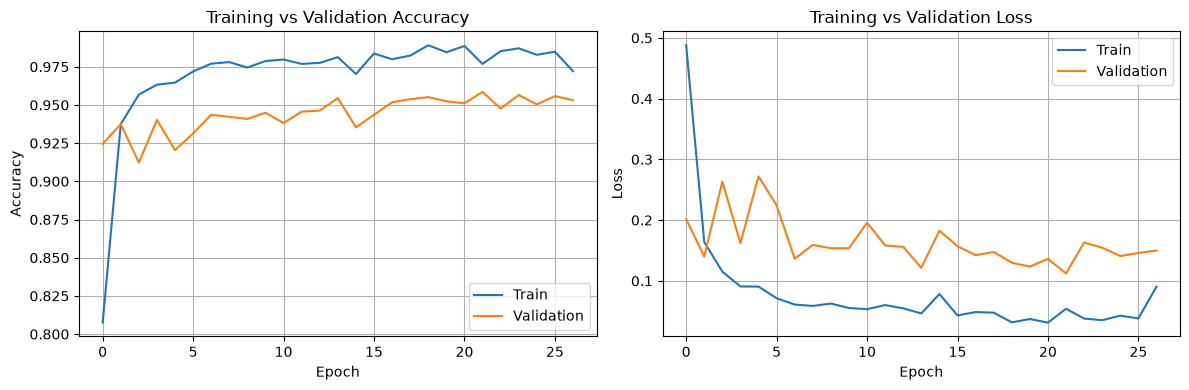

In [8]:
hist = history.history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist["accuracy"], label="Train")
axes[0].plot(hist["val_accuracy"], label="Validation")
axes[0].set_title("Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(hist["loss"], label="Train")
axes[1].plot(hist["val_loss"], label="Validation")
axes[1].set_title("Training vs Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 7. Evaluate the Baseline Keras Model


Baseline Keras Test Accuracy: 0.9386

                    precision    recall  f1-score   support

           WALKING     0.9428    0.9637    0.9531       496
  WALKING_UPSTAIRS     0.9533    0.9108    0.9316       471
WALKING_DOWNSTAIRS     0.9236    0.9500    0.9366       420
           SITTING     0.9576    0.8737    0.9137       491
          STANDING     0.8666    0.9643    0.9128       532
            LAYING     1.0000    0.9646    0.9820       537

          accuracy                         0.9386      2947
         macro avg     0.9406    0.9379    0.9383      2947
      weighted avg     0.9409    0.9386    0.9388      2947



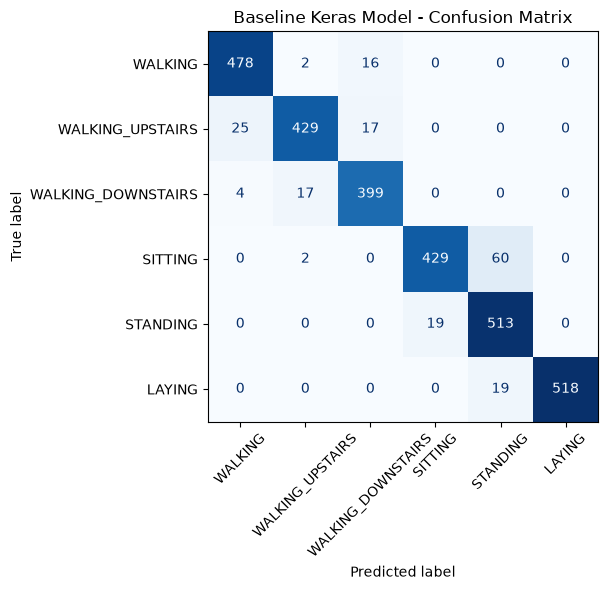

In [9]:
# 1. Predicted probabilities on the test set
baseline_probs = baseline_model.predict(X_test, verbose=0)

# 2. Convert probabilities to class predictions
baseline_preds = np.argmax(baseline_probs, axis=1)

# 3. Test accuracy
baseline_keras_acc = accuracy_score(y_test, baseline_preds)
print(f"Baseline Keras Test Accuracy: {baseline_keras_acc:.4f}\n")

# 4. Classification report
print(classification_report(y_test, baseline_preds, target_names=class_names, digits=4))

# 5. Confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, baseline_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Baseline Keras Model - Confusion Matrix")
plt.tight_layout()
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [10]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item is a single-sample batch of shape (1, num_features).
    for i in range(300):
        sample = X_train[i:i + 1].astype(np.float32)
        yield [sample]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # Quantize the input only when the model expects int8/uint8.
        # Otherwise cast to the required floating-point dtype (fp32 / fp16).
        if input_details["dtype"] in (np.int8, np.uint8):
            x = np.round(x / input_scale + input_zero_point).astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # Dequantize the output back to float32 when it is quantized.
        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()

## 9. Post-Training Quantization (PTQ)


In [11]:
# Convert the baseline model into four TFLite formats, save each to disk,
# record its size (KB), and evaluate it on the test set.
ptq_results = []

# --- FP32 ---
fp32_tflite = convert_to_tflite_fp32(baseline_model)
fp32_size = save_binary_model(fp32_tflite, "baseline_fp32.tflite")
fp32_acc, _ = evaluate_tflite_model(fp32_tflite, X_test, y_test)
ptq_results.append(("Baseline", "FP32", fp32_acc, fp32_size))

# --- Dynamic range ---
dyn_tflite = convert_to_tflite_dynamic_range(baseline_model)
dyn_size = save_binary_model(dyn_tflite, "baseline_dynamic_range.tflite")
dyn_acc, _ = evaluate_tflite_model(dyn_tflite, X_test, y_test)
ptq_results.append(("Baseline", "Dynamic Range", dyn_acc, dyn_size))

# --- Float16 ---
fp16_tflite = convert_to_tflite_float16(baseline_model)
fp16_size = save_binary_model(fp16_tflite, "baseline_float16.tflite")
fp16_acc, _ = evaluate_tflite_model(fp16_tflite, X_test, y_test)
ptq_results.append(("Baseline", "Float16", fp16_acc, fp16_size))

# --- INT8 (full integer) ---
int8_tflite = convert_to_tflite_int8(baseline_model)
int8_size = save_binary_model(int8_tflite, "baseline_int8.tflite")
int8_acc, int8_preds = evaluate_tflite_model(int8_tflite, X_test, y_test)
ptq_results.append(("Baseline", "INT8", int8_acc, int8_size))

for _, fmt, acc, size in ptq_results:
    print(f"{fmt:15s}  accuracy={acc:.4f}  size={size:8.2f} KB")

INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp5d_kgzzk/assets


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp5d_kgzzk/assets


W0000 00:00:1784154059.046372 54226644 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784154059.046385 54226644 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1784154059.046646 54226644 reader.cc:83] Reading SavedModel from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp5d_kgzzk
I0000 00:00:1784154059.047604 54226644 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1784154059.047609 54226644 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp5d_kgzzk
I0000 00:00:1784154059.053749 54226644 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1784154059.054754 54226644 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1784154059.097079 54226644 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp5d_kgzzk
I0000 00:00:1784154059.108834 54

INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpjpe3tm3g/assets


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmpjpe3tm3g/assets


...

INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp3nxgxfr0/assets


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp3nxgxfr0/assets


/Users/lukevalerio/miniconda3/lib/python3.13/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1784154061.962335 54226644 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784154061.962346 54226644 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1784154061.962496 54226644 reader.cc:83] Reading SavedModel from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp3nxgxfr0
I0000 00:00:1784154061.963413 54226644 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1784154061.963417 54226644 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmp3nxgxfr0
I0000 00:00:1784154061.970462 54226644 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1784154062.012629 54226644 loader.cc:220] Running initialization op on SavedModel bundle at pat

FP32             accuracy=0.9386  size=  726.74 KB
Dynamic Range    accuracy=0.9386  size=  191.34 KB
Float16          accuracy=0.9386  size=  365.73 KB
INT8             accuracy=0.9376  size=  195.91 KB


W0000 00:00:1784154062.157881 54226644 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.
/Users/lukevalerio/miniconda3/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 10. PTQ Comparison: Accuracy and Model Size


In [12]:
ptq_df = pd.DataFrame(
    ptq_results,
    columns=["Model Family", "Format", "Test Accuracy", "Model Size (KB)"],
)
ptq_df

,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline,FP32,0.938582,726.738281
1,Baseline,Dynamic Range,0.938582,191.335938
2,Baseline,Float16,0.938582,365.730469
3,Baseline,INT8,0.937564,195.906250


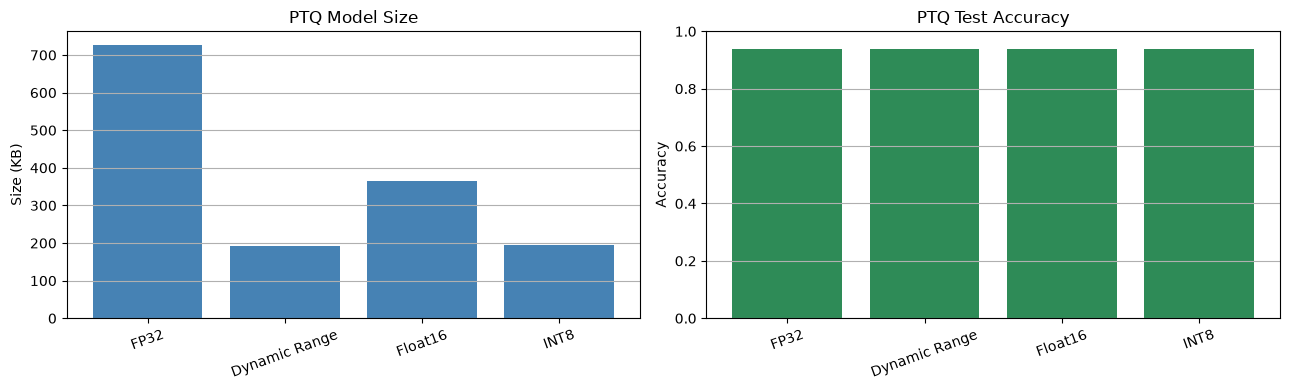

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(ptq_df["Format"], ptq_df["Model Size (KB)"], color="steelblue")
axes[0].set_title("PTQ Model Size")
axes[0].set_ylabel("Size (KB)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y")

axes[1].bar(ptq_df["Format"], ptq_df["Test Accuracy"], color="seagreen")
axes[1].set_title("PTQ Test Accuracy")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


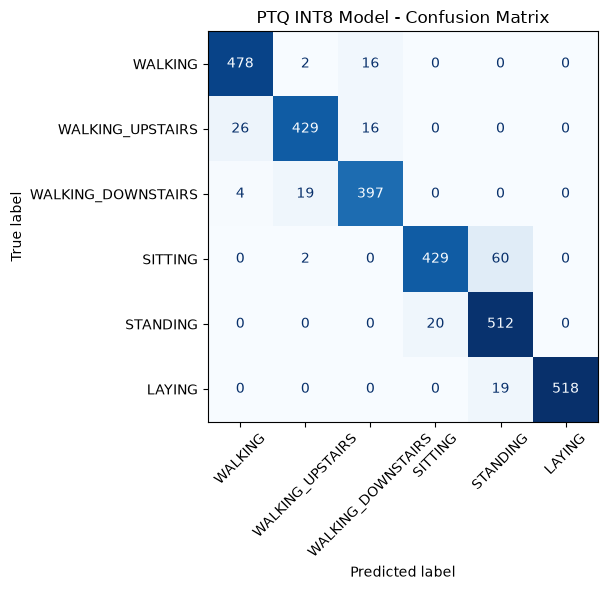

                    precision    recall  f1-score   support

           WALKING     0.9409    0.9637    0.9522       496
  WALKING_UPSTAIRS     0.9491    0.9108    0.9296       471
WALKING_DOWNSTAIRS     0.9254    0.9452    0.9352       420
           SITTING     0.9555    0.8737    0.9128       491
          STANDING     0.8663    0.9624    0.9118       532
            LAYING     1.0000    0.9646    0.9820       537

          accuracy                         0.9376      2947
         macro avg     0.9395    0.9368    0.9373      2947
      weighted avg     0.9397    0.9376    0.9377      2947



In [14]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, int8_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("PTQ INT8 Model - Confusion Matrix")
plt.tight_layout()
plt.show()

print(classification_report(y_test, int8_preds, target_names=class_names, digits=4))

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [15]:
# Wrap the trained baseline model with quantization-aware training wrappers.
qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

qat_model.summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 quantize_layer (QuantizeLa  (None, 561)               3         


 yer)                                                            


...

 pperV2)                                                         


Total params: 185437 (724.36 KB)


Trainable params: 185414 (724.27 KB)


Non-trainable params: 23 (92.00 Byte)


_________________________________________________________________


### Fine-Tune the QAT Model


In [16]:
qat_history = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1,
)

Epoch 1/8



 1/92 [..............................] - ETA: 1:10 - loss: 0.0616 - accuracy: 0.9688


25/92 [=======>......................] - ETA: 0s - loss: 0.0301 - accuracy: 0.9919  


50/92 [===============>..............] - ETA: 0s - loss: 0.0304 - accuracy: 0.9919


75/92 [=======================>......] - ETA: 0s - loss: 0.0311 - accuracy: 0.9908

...


18/92 [====>.........................] - ETA: 0s - loss: 0.0188 - accuracy: 0.9939


37/92 [===========>..................] - ETA: 0s - loss: 0.0175 - accuracy: 0.9941


56/92 [=================>............] - ETA: 0s - loss: 0.0198 - accuracy: 0.9933


78/92 [========================>.....] - ETA: 0s - loss: 0.0193 - accuracy: 0.9940


92/92 [==============================] - 0s 3ms/step - loss: 0.0186 - accuracy: 0.9942 - val_loss: 0.1471 - val_accuracy: 0.9565


### Evaluate the QAT Keras Model


In [17]:
qat_probs = qat_model.predict(X_test, verbose=0)
qat_preds = np.argmax(qat_probs, axis=1)
qat_keras_acc = accuracy_score(y_test, qat_preds)

print(f"QAT Keras Test Accuracy: {qat_keras_acc:.4f}\n")
print(classification_report(y_test, qat_preds, target_names=class_names, digits=4))

QAT Keras Test Accuracy: 0.9379



                    precision    recall  f1-score   support

           WALKING     0.9209    0.9859    0.9523       496
  WALKING_UPSTAIRS     0.9329    0.9151    0.9239       471
WALKING_DOWNSTAIRS     0.9722    0.9167    0.9436       420
           SITTING     0.9596    0.8717    0.9136       491
          STANDING     0.8639    0.9662    0.9122       532
            LAYING     1.0000    0.9628    0.9810       537

          accuracy                         0.9379      2947
         macro avg     0.9416    0.9364    0.9378      2947
      weighted avg     0.9407    0.9379    0.9381      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [18]:
# For a QAT model the quantization ranges were learned during fine-tuning,
# so a representative dataset is not required. We apply the default optimization
# and force int8 input/output for a fully-integer deployable model.
converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
qat_int8_tflite = converter.convert()

qat_int8_size = save_binary_model(qat_int8_tflite, "qat_int8.tflite")
qat_int8_acc, qat_int8_preds = evaluate_tflite_model(qat_int8_tflite, X_test, y_test)

print(f"QAT INT8 Test Accuracy: {qat_int8_acc:.4f}")
print(f"QAT INT8 Model Size (KB): {qat_int8_size:.2f}")

INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmprfhob956/assets


INFO:tensorflow:Assets written to: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmprfhob956/assets


/Users/lukevalerio/miniconda3/lib/python3.13/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1784154069.530510 54226644 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784154069.530524 54226644 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


QAT INT8 Test Accuracy: 0.9379
QAT INT8 Model Size (KB): 186.02


I0000 00:00:1784154069.530717 54226644 reader.cc:83] Reading SavedModel from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmprfhob956
I0000 00:00:1784154069.532963 54226644 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1784154069.532978 54226644 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmprfhob956
I0000 00:00:1784154069.550035 54226644 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1784154069.626201 54226644 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/_6/dlf_px9j4jl_nlqtql_xp0jr0000gq/T/tmprfhob956
I0000 00:00:1784154069.648277 54226644 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 117564 microseconds.
/Users/lukevalerio/miniconda3/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please

## 12. PTQ Int8 vs QAT Int8


In [19]:
ptq_vs_qat_df = pd.DataFrame(
    [
        ["PTQ INT8", int8_acc, int8_size],
        ["QAT INT8", qat_int8_acc, qat_int8_size],
    ],
    columns=["Model", "Test Accuracy", "Model Size (KB)"],
)
ptq_vs_qat_df

,Model,Test Accuracy,Model Size (KB)
0,PTQ INT8,0.937564,195.906250
1,QAT INT8,0.937903,186.015625


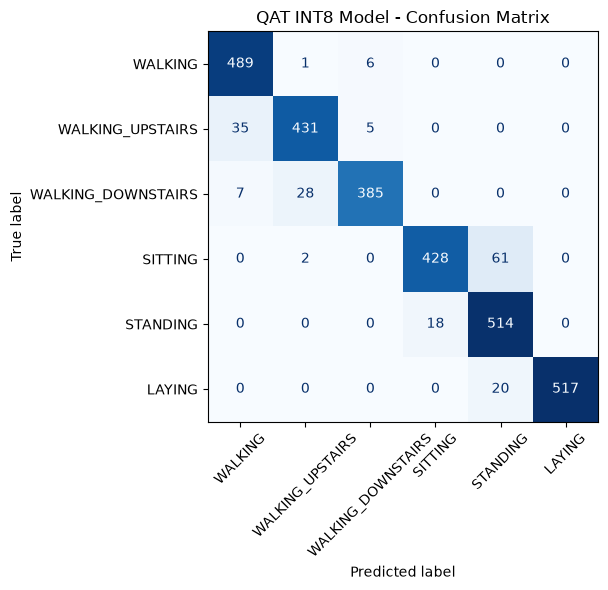

                    precision    recall  f1-score   support

           WALKING     0.9209    0.9859    0.9523       496
  WALKING_UPSTAIRS     0.9329    0.9151    0.9239       471
WALKING_DOWNSTAIRS     0.9722    0.9167    0.9436       420
           SITTING     0.9596    0.8717    0.9136       491
          STANDING     0.8639    0.9662    0.9122       532
            LAYING     1.0000    0.9628    0.9810       537

          accuracy                         0.9379      2947
         macro avg     0.9416    0.9364    0.9378      2947
      weighted avg     0.9407    0.9379    0.9381      2947



In [20]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, qat_int8_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("QAT INT8 Model - Confusion Matrix")
plt.tight_layout()
plt.show()

print(classification_report(y_test, qat_int8_preds, target_names=class_names, digits=4))

## 13. Summary Questions

**1. Which quantization method gave the smallest model size?**

The quantization technique that had the smallest model size was the int8 quantization that also included quantization aware training. It came in at 186 KB, which was even a little smaller than the post training int8 model.

**2. Which quantization method gave the best accuracy among the TensorFlow Lite models?**

Float16 matched float32 and dynamic range, and all three tied at 0.9386. The accuracy stays the same because the activations were not quantized in these versions. Only the way the weights are stored differs, so this keeps the accuracy the same as the original model.

**3. Did quantization aware training improve the final int8 model compared with post training int8?**

Yes it did, but only slightly. The quantization aware training version hit 0.9379 while the post training version got 0.9376, so it was a very small gain. This gain was small because the input data was already clean and normalized, so we already got most of the benefit in the post training quantization and the aware training had little left to add.

**4. Why is this dataset a good fit for a DNN-based TinyML workflow?**

This dataset was good for the dense neural network because it had simple features that were already extracted from the raw signal, so they could be densely connected without much work. There was no time series or image data that would require a convolutional or recurrent network. This keeps the model small, and it lets our quantization be extra effective so it can fit on a microcontroller.

**5. If you were deploying this model on a resource-constrained device, which version would you choose and why?**

I would choose the int8 model with quantization aware training. It was the smallest at 186 KB, it runs with all integer math which is faster and uses less power on a microcontroller that often has no floating point unit, and it barely lost any accuracy compared to the float32 baseline (0.9379 versus 0.9386). If I could not retrain the model I would use the post training int8 version instead, and if the device had good floating point support and extra room I would think about float16.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
